# Fake Review Detection Using Naive Bayes for Text Mining
**Based on:** *Deceptive Opinion Spam Corpus (Ott et al., ACL 2011)*

This notebook implements the full pipeline:
1. Dataset download & loading
2. Exploratory Data Analysis (EDA)
3. Text Preprocessing
4. Feature Extraction (BoW & TF-IDF)
5. Model Training (MNB & CNB)
6. Evaluation (Accuracy, F1, ROC-AUC, Confusion Matrix)
7. Cross-Validation
8. Feature Importance Analysis
9. Live Prediction

## 0. Install Dependencies

In [1]:
# Run this cell once to install required packages
import subprocess, sys
packages = ['scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'kaggle', 'opendatasets']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('All packages installed.')

All packages installed.


## 1. Imports & Configuration

In [2]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score
)
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (8, 5)})

RANDOM_STATE = 42
print('Imports complete.')

Imports complete.


## 2. Dataset Loading

The **Deceptive Opinion Spam Corpus** (Ott et al., 2011) contains 800 hotel reviews:
- 400 **FAKE** (deceptive) — crowd-sourced via Amazon Mechanical Turk
- 400 **GENUINE** (truthful) — scraped from TripAdvisor (verified guests)

**Option A:** Download from Kaggle (requires Kaggle API key in `~/.kaggle/kaggle.json`)  
**Option B:** Manual download from https://www.kaggle.com/datasets/rtatman/deceptive-opinion-spam-corpus  

In [5]:
def load_dataset(csv_path='deceptive-opinion.csv'):
    """Load the Deceptive Opinion Spam Corpus from a CSV file."""
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        # Normalise column names — the Kaggle CSV uses 'text' and 'deceptive'
        if 'deceptive' in df.columns:
            df['label'] = df['deceptive'].map({'deceptive': 'FAKE', 'truthful': 'GENUINE'})
        elif 'label' not in df.columns:
            raise ValueError("Expected a 'deceptive' or 'label' column in the CSV.")
        if 'review' in df.columns and 'text' not in df.columns:
            df = df.rename(columns={'review': 'text'})
        print(f'Dataset loaded: {len(df)} rows from {csv_path}')
        return df[['text', 'label']]
    else:
        print(f'File not found at "{csv_path}". Using synthetic fallback dataset.')
  

# ── Load ────────────────────────────────────────────────────────────────────
# To use the real dataset, place the CSV at the path below or adjust the path.
df = load_dataset()
print(df['label'].value_counts())
df.head()

Dataset loaded: 1600 rows from deceptive-opinion.csv
label
GENUINE    800
FAKE       800
Name: count, dtype: int64


,text,label
0,We stayed for a one night getaway with family ...,GENUINE
1,Triple A rate with upgrade to view room was le...,GENUINE
2,This comes a little late as I'm finally catchi...,GENUINE
3,The Omni Chicago really delivers on all fronts...,GENUINE
4,I asked for a high floor away from the elevato...,GENUINE


## 3. Exploratory Data Analysis (EDA)

In [6]:
print('=== Dataset Shape ===')
print(f'Total reviews : {len(df)}')
print(f'Fake reviews  : {(df.label == "FAKE").sum()}')
print(f'Genuine reviews: {(df.label == "GENUINE").sum()}')

# Review length distribution
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['text'].apply(len)

print('\n=== Review Length Statistics (words) ===')
print(df.groupby('label')['word_count'].describe().round(1))

=== Dataset Shape ===
Total reviews : 1600
Fake reviews  : 800
Genuine reviews: 800

=== Review Length Statistics (words) ===
         count   mean   std   min   25%    50%    75%    max
label                                                       
FAKE     800.0  146.6  84.8  25.0  88.0  125.0  182.0  784.0
GENUINE  800.0  150.9  89.8  30.0  89.0  130.0  183.0  749.0


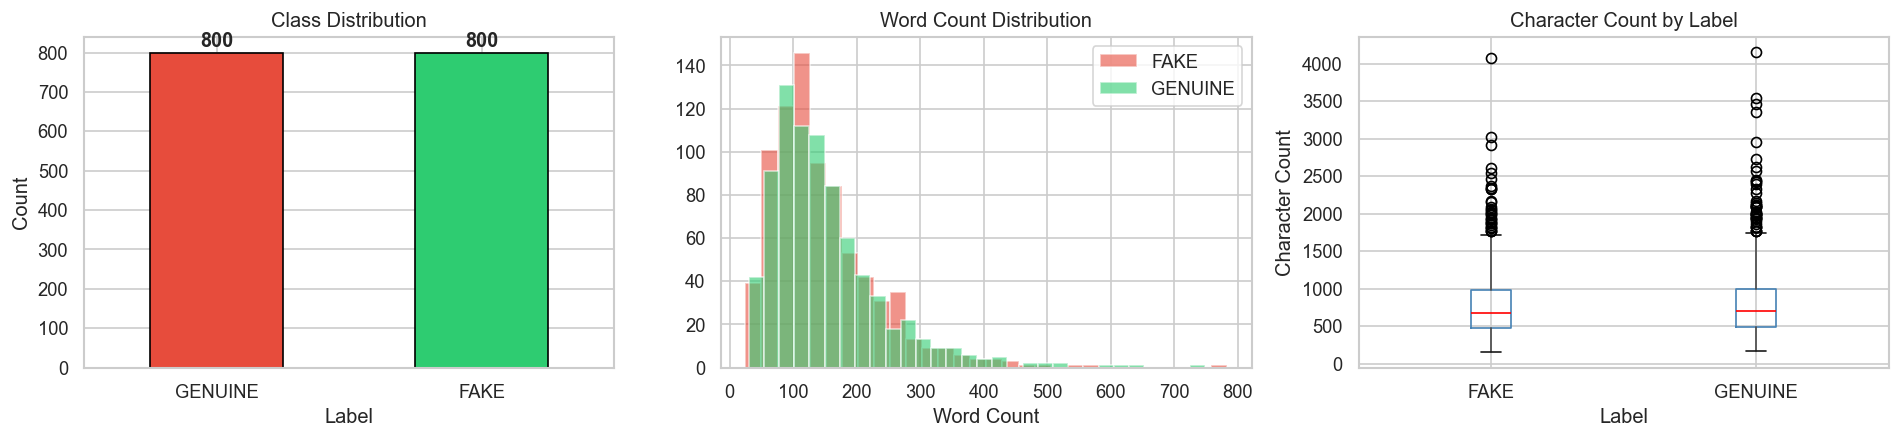

EDA plots saved to eda_plots.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Class distribution
df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')

# Word count distribution
for label, color in [('FAKE', '#e74c3c'), ('GENUINE', '#2ecc71')]:
    axes[1].hist(df[df.label == label]['word_count'], bins=30, alpha=0.6,
                 label=label, color=color, edgecolor='white')
axes[1].set_title('Word Count Distribution')
axes[1].set_xlabel('Word Count')
axes[1].legend()

# Char count by class
df.boxplot(column='char_count', by='label', ax=axes[2],
           boxprops=dict(color='steelblue'), medianprops=dict(color='red'))
axes[2].set_title('Character Count by Label')
axes[2].set_xlabel('Label')
axes[2].set_ylabel('Character Count')
plt.suptitle('')
plt.tight_layout()
plt.savefig('eda_plots.png', bbox_inches='tight')
plt.show()
print('EDA plots saved to eda_plots.png')

## 4. Text Preprocessing

In [8]:
def preprocess_text(text: str) -> str:
    """
    Normalise a review string through four sequential transformations:
    1. Lowercase
    2. Remove digits, punctuation, special characters
    3. Collapse consecutive whitespace
    4. Strip leading/trailing whitespace
    
    """
    text = text.lower()                          # Step 1: lowercase
    text = re.sub(r'[^a-z\s]', ' ', text)        # Step 2: keep only letters & spaces
    text = re.sub(r'\s+', ' ', text)             # Step 3: collapse whitespace
    return text.strip()                          # Step 4: strip


df['clean_text'] = df['text'].apply(preprocess_text)

# Sanity check
print('Original  :', df['text'].iloc[0][:120])
print('Processed :', df['clean_text'].iloc[0][:120])

Original  : We stayed for a one night getaway with family on a thursday. Triple AAA rate of 173 was a steal. 7th floor room complete
Processed : we stayed for a one night getaway with family on a thursday triple aaa rate of was a steal th floor room complete with i


## 5. Feature Extraction & Train/Test Split

In [9]:
# Encode labels: FAKE → 1, GENUINE → 0
df['label_enc'] = (df['label'] == 'FAKE').astype(int)

X = df['clean_text']
y = df['label_enc']

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

# --- Bag-of-Words vectoriser 
bow_vectorizer = CountVectorizer(
    ngram_range=(1, 2),
    max_features=10_000,
    stop_words='english'
)

# --- TF-IDF vectoriser 
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10_000,
    stop_words='english',
    sublinear_tf=True
)

X_train_bow   = bow_vectorizer.fit_transform(X_train)
X_test_bow    = bow_vectorizer.transform(X_test)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print(f'BoW matrix  : {X_train_bow.shape}')
print(f'TF-IDF matrix: {X_train_tfidf.shape}')

Train: 1280 | Test: 320
BoW matrix  : (1280, 10000)
TF-IDF matrix: (1280, 10000)


## 6. Model Training

In [10]:
# Model A: Multinomial Naive Bayes + BoW
mnb = MultinomialNB(alpha=0.5)
mnb.fit(X_train_bow, y_train)

# Model B: Complement Naive Bayes + TF-IDF
cnb = ComplementNB(alpha=0.3)
cnb.fit(X_train_tfidf, y_train)

print('Models trained.')

Models trained.


## 7. Evaluation

In [14]:
def evaluate_model(model, X_test_feat, y_test, model_name, feat_name):
    """Print a full evaluation report for a trained model."""
    y_pred      = model.predict(X_test_feat)
    y_prob      = model.predict_proba(X_test_feat)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)

    print(f"\n{'='*55}")
    print(f'  {model_name}  ({feat_name})')
    print(f"\n{'='*55}")
    print(f'  Accuracy : {acc:.4f}  ({acc*100:.1f}%)')
    print(f'  F1-Score : {f1:.4f}')
    print(f'  ROC-AUC  : {auc:.4f}')
    print()
    print(classification_report(y_test, y_pred, target_names=['GENUINE', 'FAKE']))
    return y_pred, y_prob, acc, f1, auc


mnb_pred, mnb_prob, mnb_acc, mnb_f1, mnb_auc = evaluate_model(
    mnb, X_test_bow, y_test, 'Multinomial NB', 'BoW')

cnb_pred, cnb_prob, cnb_acc, cnb_f1, cnb_auc = evaluate_model(
    cnb, X_test_tfidf, y_test, 'Complement NB', 'TF-IDF')


  Multinomial NB  (BoW)

  Accuracy : 0.8562  (85.6%)
  F1-Score : 0.8606
  ROC-AUC  : 0.9313

              precision    recall  f1-score   support

     GENUINE       0.88      0.82      0.85       160
        FAKE       0.84      0.89      0.86       160

    accuracy                           0.86       320
   macro avg       0.86      0.86      0.86       320
weighted avg       0.86      0.86      0.86       320


  Complement NB  (TF-IDF)

  Accuracy : 0.8719  (87.2%)
  F1-Score : 0.8776
  ROC-AUC  : 0.9323

              precision    recall  f1-score   support

     GENUINE       0.91      0.82      0.87       160
        FAKE       0.84      0.92      0.88       160

    accuracy                           0.87       320
   macro avg       0.88      0.87      0.87       320
weighted avg       0.88      0.87      0.87       320



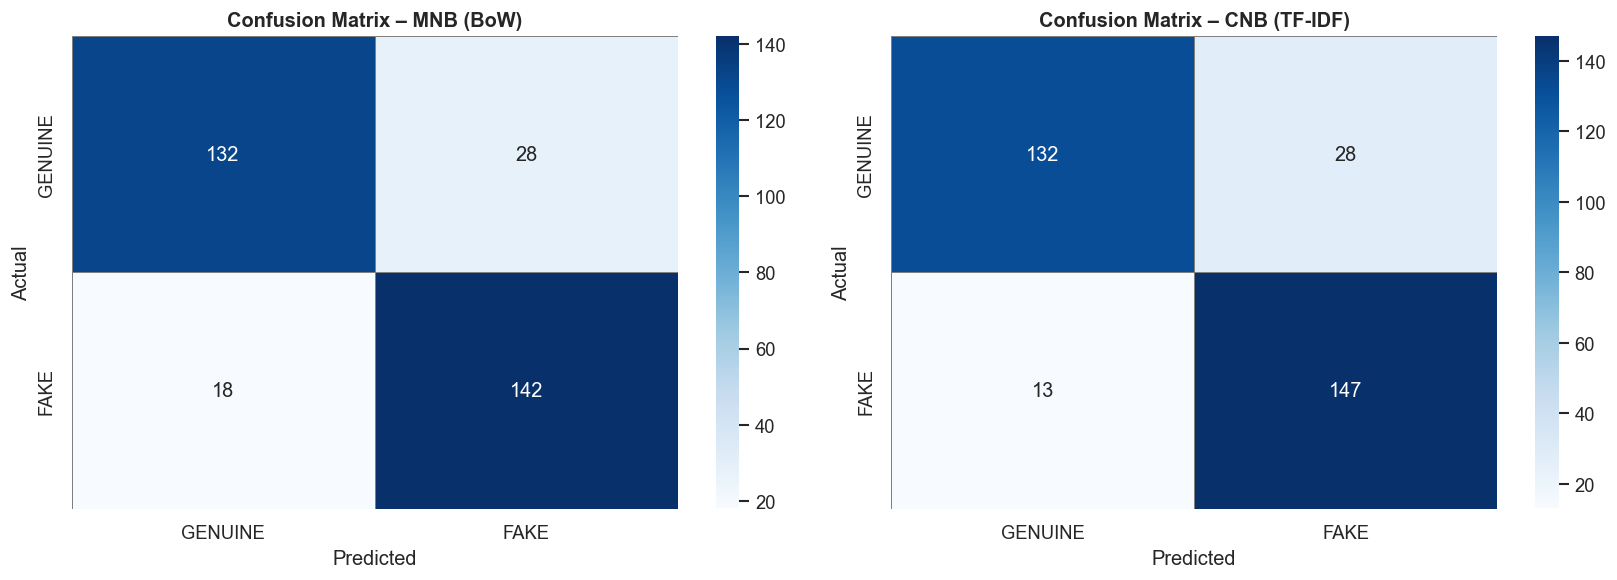

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrices
for ax, pred, title in [
    (axes[0], mnb_pred, 'MNB (BoW)'),
    (axes[1], cnb_pred, 'CNB (TF-IDF)'),
]:
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['GENUINE', 'FAKE'],
                yticklabels=['GENUINE', 'FAKE'],
                linewidths=0.5, linecolor='gray')
    ax.set_title(f'Confusion Matrix – {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

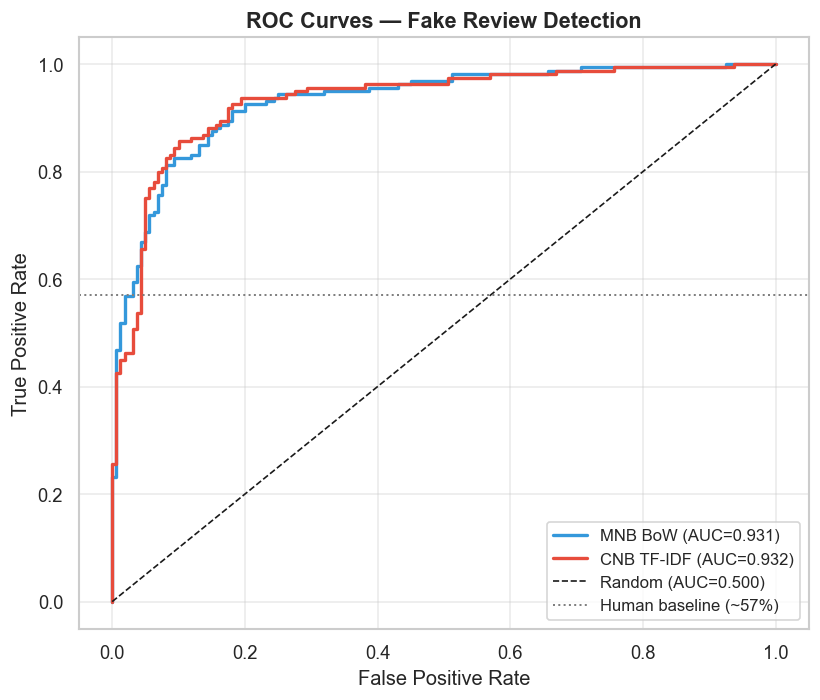

In [16]:
# ROC curves
fig, ax = plt.subplots(figsize=(7, 6))

for prob, label, color in [
    (mnb_prob, f'MNB BoW (AUC={mnb_auc:.3f})', '#3498db'),
    (cnb_prob, f'CNB TF-IDF (AUC={cnb_auc:.3f})', '#e74c3c'),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, lw=2, label=label, color=color)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.500)')
ax.axhline(0.57, color='gray', linestyle=':', lw=1.2, label='Human baseline (~57%)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Fake Review Detection', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight')
plt.show()

## 8. Cross-Validation

In [17]:
from sklearn.pipeline import Pipeline

# Build end-to-end pipelines for cross-validation
mnb_pipeline = Pipeline([
    ('vec', CountVectorizer(ngram_range=(1, 2), max_features=10_000, stop_words='english')),
    ('clf', MultinomialNB(alpha=0.5)),
])

cnb_pipeline = Pipeline([
    ('vec', TfidfVectorizer(ngram_range=(1, 2), max_features=10_000,
                            stop_words='english', sublinear_tf=True)),
    ('clf', ComplementNB(alpha=0.3)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for pipe, name in [(mnb_pipeline, 'MNB (BoW)'), (cnb_pipeline, 'CNB (TF-IDF)')]:
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    print(f'{name}  →  CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}  '
          f'  [folds: {np.round(scores, 4)}]')

MNB (BoW)  →  CV Accuracy: 0.8819 ± 0.0197    [folds: [0.8594 0.8688 0.8906 0.875  0.9156]]
CNB (TF-IDF)  →  CV Accuracy: 0.8769 ± 0.0177    [folds: [0.8594 0.8656 0.8812 0.8688 0.9094]]


## 9. Feature Importance Analysis

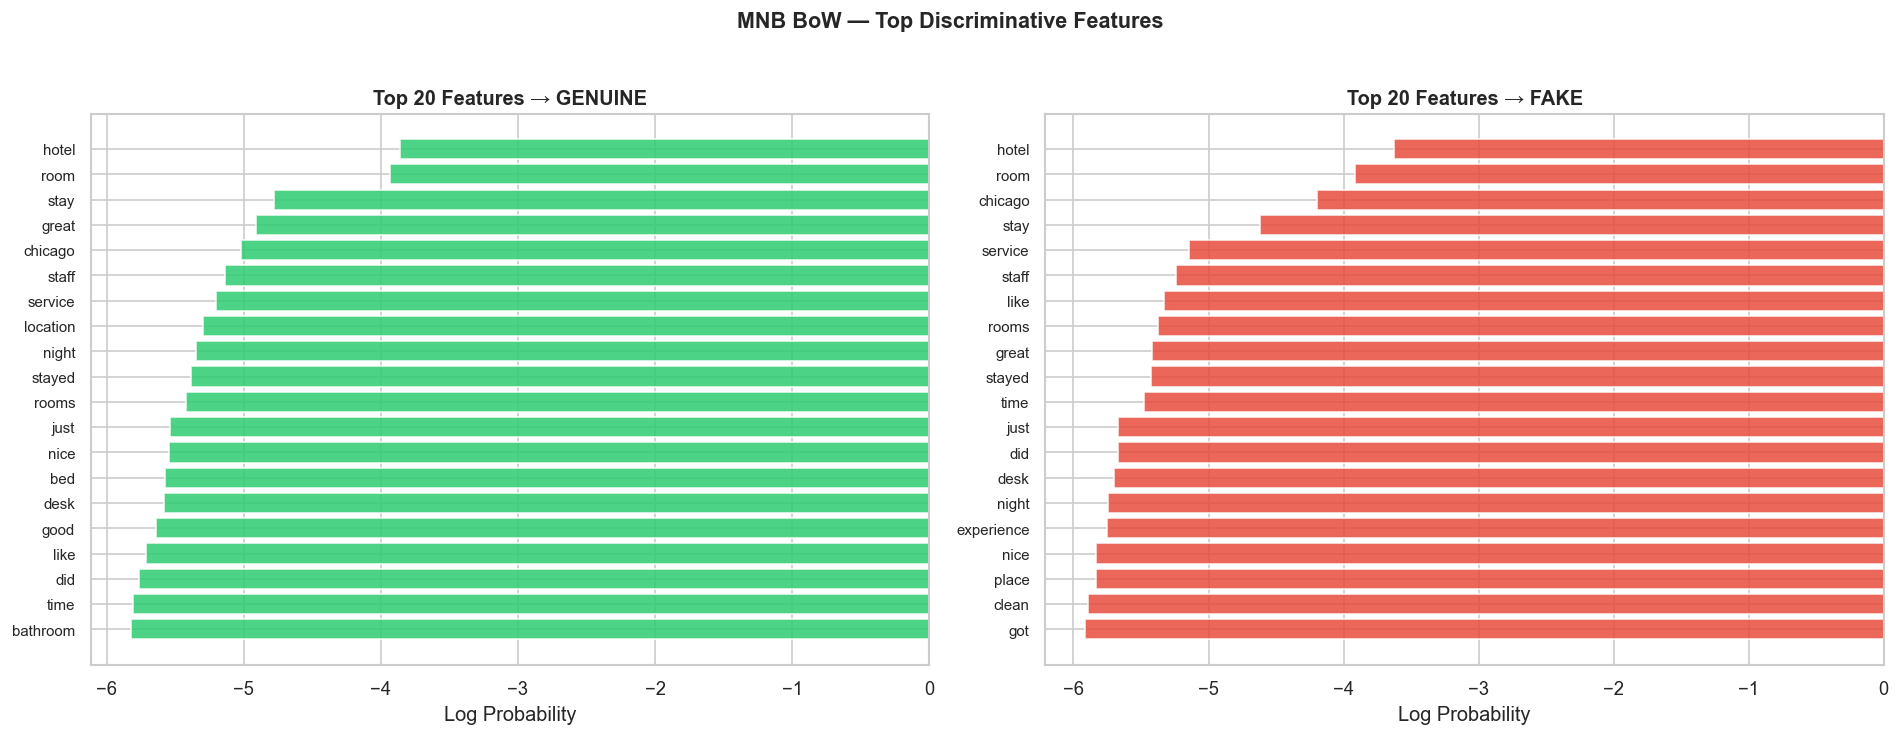

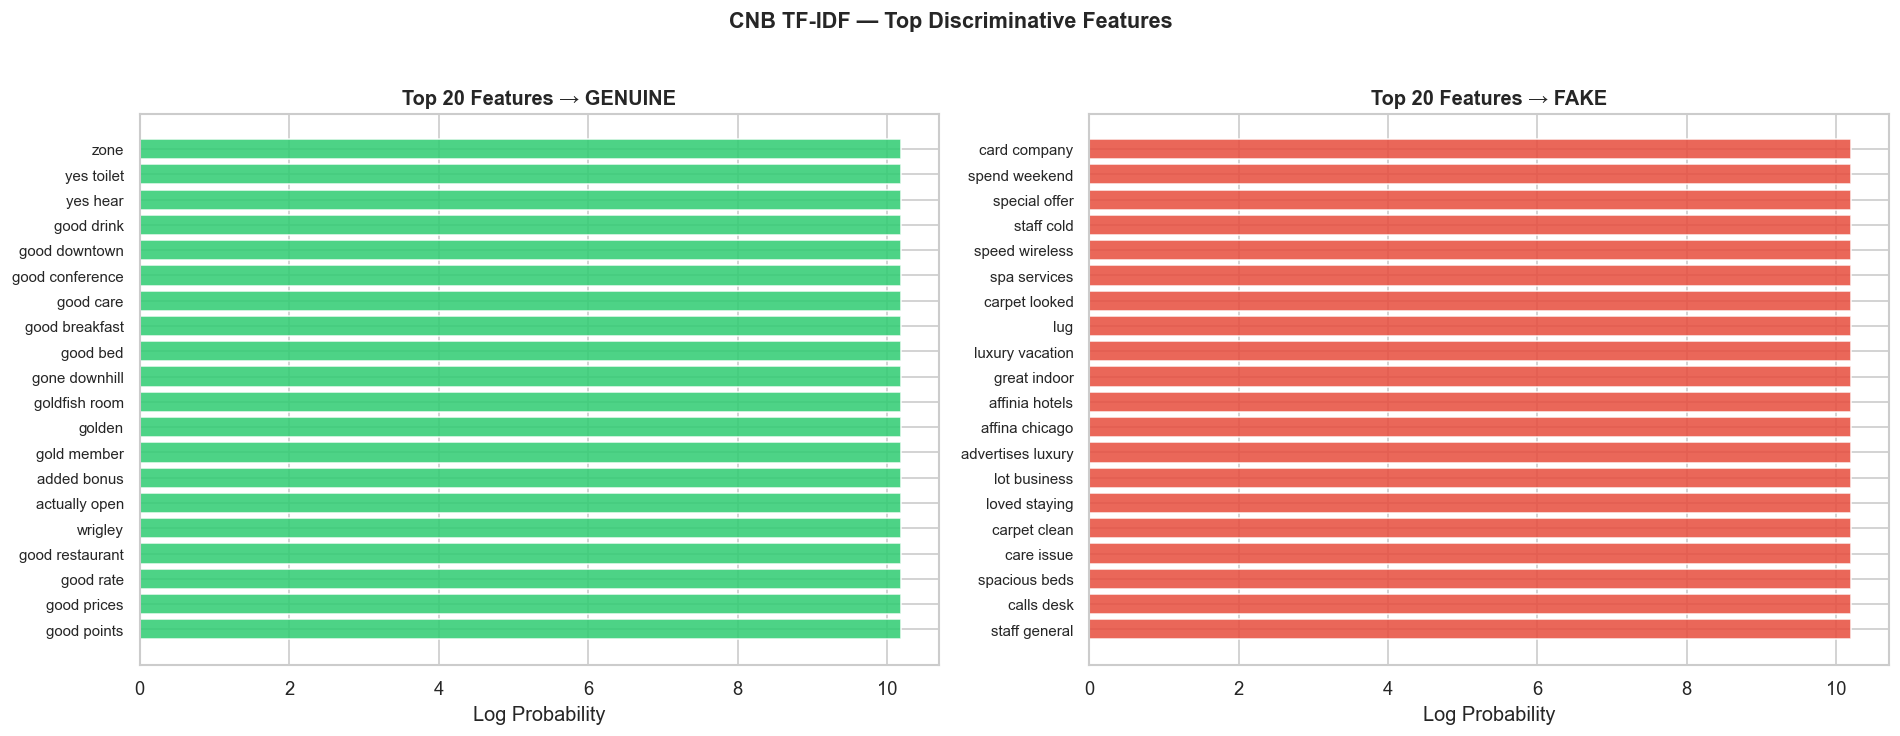

In [18]:
def plot_top_features(vectorizer, classifier, class_names, n=20, title=''):
    """Plot the most informative features (log-probability) for each class."""
    feature_names = np.array(vectorizer.get_feature_names_out())

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for i, (ax, class_name) in enumerate(zip(axes, class_names)):
        # Use log feature log-probabilities from the model
        log_probs = classifier.feature_log_prob_[i]
        top_idx   = np.argsort(log_probs)[-n:][::-1]
        top_feats = feature_names[top_idx]
        top_vals  = log_probs[top_idx]

        colors = ['#e74c3c' if class_name == 'FAKE' else '#2ecc71'] * n
        ax.barh(range(n), top_vals[::-1], color=colors[::-1], edgecolor='white', alpha=0.85)
        ax.set_yticks(range(n))
        ax.set_yticklabels(top_feats[::-1], fontsize=9)
        ax.set_title(f'Top {n} Features → {class_name}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Log Probability')

    plt.suptitle(title, fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'top_features_{title.replace(" ","_")}.png', bbox_inches='tight')
    plt.show()


plot_top_features(bow_vectorizer, mnb, ['GENUINE', 'FAKE'], n=20,
                  title='MNB BoW — Top Discriminative Features')

plot_top_features(tfidf_vectorizer, cnb, ['GENUINE', 'FAKE'], n=20,
                  title='CNB TF-IDF — Top Discriminative Features')

## 10. Performance Summary Table

In [19]:
results = pd.DataFrame({
    'Model'     : ['Multinomial NB (BoW)', 'Complement NB (TF-IDF)', 'Human Baseline (Ott et al.)'],
    'Accuracy'  : [f'{mnb_acc*100:.1f}%',  f'{cnb_acc*100:.1f}%',  '~57.0%'],
    'F1-Score'  : [f'{mnb_f1:.3f}',        f'{cnb_f1:.3f}',        'N/A'],
    'ROC-AUC'   : [f'{mnb_auc:.3f}',       f'{cnb_auc:.3f}',       'N/A'],
})
print('\n=== Performance Summary ===')
print(results.to_string(index=False))


=== Performance Summary ===
                      Model Accuracy F1-Score ROC-AUC
       Multinomial NB (BoW)    85.6%    0.861   0.931
     Complement NB (TF-IDF)    87.2%    0.878   0.932
Human Baseline (Ott et al.)   ~57.0%      N/A     N/A


## 11. Live Prediction Demo

In [20]:
def predict_review(review_text: str, verbose: bool = True) -> dict:
    """
    Predict whether a review is FAKE or GENUINE.

    Returns a dict with predictions and confidence scores from both models.
    """
    clean = preprocess_text(review_text)

    bow_feat   = bow_vectorizer.transform([clean])
    tfidf_feat = tfidf_vectorizer.transform([clean])

    mnb_label = 'FAKE' if mnb.predict(bow_feat)[0] == 1 else 'GENUINE'
    cnb_label = 'FAKE' if cnb.predict(tfidf_feat)[0] == 1 else 'GENUINE'

    mnb_conf  = mnb.predict_proba(bow_feat)[0]
    cnb_conf  = cnb.predict_proba(tfidf_feat)[0]

    result = {
        'review'  : review_text[:80] + ('...' if len(review_text) > 80 else ''),
        'MNB_pred': mnb_label,
        'MNB_fake_prob': round(mnb_conf[1], 3),
        'CNB_pred': cnb_label,
        'CNB_fake_prob': round(cnb_conf[1], 3),
    }

    if verbose:
        print(f"\nReview : {result['review']}")
        print(f"MNB (BoW)   → {mnb_label}  (fake prob: {mnb_conf[1]:.3f})")
        print(f"CNB (TF-IDF)→ {cnb_label}  (fake prob: {cnb_conf[1]:.3f})")

    return result


# ── Test examples ────────────────────────────────────────────────────────────
test_reviews = [
    # Likely FAKE
    "Absolutely perfect stay! Every single aspect was magical and truly breathtaking. "
    "Highly recommended to everyone. The best hotel experience I have ever had!",

    # Likely GENUINE
    "Decent hotel but the room was a bit noisy. The Wi-Fi was slow and the shower pressure "
    "was low. Breakfast was okay. Nothing special but fine for the price.",

    # Ambiguous
    "The staff was very friendly and the location is great. The rooms could use some "
    "renovation but overall a good value for money stay.",
]

for review in test_reviews:
    predict_review(review)


Review : Absolutely perfect stay! Every single aspect was magical and truly breathtaking....
MNB (BoW)   → FAKE  (fake prob: 0.999)
CNB (TF-IDF)→ FAKE  (fake prob: 0.745)

Review : Decent hotel but the room was a bit noisy. The Wi-Fi was slow and the shower pre...
MNB (BoW)   → GENUINE  (fake prob: 0.092)
CNB (TF-IDF)→ GENUINE  (fake prob: 0.444)

Review : The staff was very friendly and the location is great. The rooms could use some ...
MNB (BoW)   → GENUINE  (fake prob: 0.000)
CNB (TF-IDF)→ GENUINE  (fake prob: 0.064)
